In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from mad.utils import load_ballistic_table, BALLISTIC_FIELD_NAMES
from mad.objs.constants import EARTH_SETTINGS
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
table = load_ballistic_table("titan_stage_2")
df = pd.DataFrame({k:table[:, i] for i, k in enumerate(BALLISTIC_FIELD_NAMES)})

17:43:11 | WARNING  | I/O          | Dropped 876 row(s) with missing values from /app/src/mad/tables/titan_stage_2.csv.


In [5]:

df["range_km"] = df["range_rad"] * EARTH_SETTINGS["radius"] / 1000
df["altitude_km"] = df["altitude_m"] / 1000
df["gamma_deg"] = df["gamma_rad"] * 180 / np.pi

df


,altitude_m,velocity_m_s,gamma_rad,range_rad,range_km,altitude_km,gamma_deg
0,0.0,1000.0,0.087266,0.000000,0.000000,0.0,5.0
1,0.0,1000.0,0.174533,0.000000,0.000000,0.0,10.0
2,0.0,1000.0,0.261799,0.000000,0.000000,0.0,15.0
3,0.0,1000.0,0.349066,0.000000,0.000000,0.0,20.0
4,0.0,1000.0,0.436332,0.000000,0.000000,0.0,25.0
...,...,...,...,...,...,...,...
1849,600000.0,8000.0,0.261799,2.474585,15765.578152,600.0,15.0
1850,600000.0,8000.0,0.349066,3.074191,19585.672138,600.0,20.0
1851,600000.0,8000.0,0.698132,2.122589,13523.012734,600.0,40.0
1852,600000.0,8000.0,0.959931,1.383787,8816.104168,600.0,55.0


In [6]:
selected_altitude = 100

df2 = df[df["altitude_km"] == selected_altitude].pivot(index="velocity_m_s", columns="gamma_deg", values="range_km")
df2

gamma_deg,5.0,10.0,15.0,20.0,25.0,30.0,35.0,40.0,45.0,50.0,55.0,60.0,65.0,70.0
velocity_m_s,,,,,,,,,,,,,,
1000.0,119.430359,127.697107,135.260444,141.722006,146.668606,149.707682,150.500536,148.784836,144.385813,137.225203,127.330637,114.808282,99.773409,82.609052
1500.0,185.620310,206.957126,228.017710,247.496095,264.055116,276.505417,283.906040,285.553670,280.817492,269.778730,252.524224,229.373186,200.289089,166.585333
2000.0,258.258174,NaN,344.458341,385.730253,421.561908,449.569317,467.803787,474.353190,471.012529,453.536390,423.893318,NaN,338.868442,283.094093
2500.0,339.718655,414.116753,491.598894,564.900485,628.378649,677.703607,708.879305,725.661550,714.911470,685.000536,655.505580,555.169864,453.191806,429.041443
3000.0,433.187114,NaN,678.445518,795.218222,894.536201,969.599860,1021.830934,1024.830275,1020.953392,878.323510,933.425828,824.179348,196.943491,NaN
3500.0,543.137081,727.502018,917.236737,1091.171954,1237.458193,1341.035940,1414.464506,1358.338988,1178.113897,1354.925913,1212.532471,1599.270163,NaN,831.269254
4000.0,676.223474,949.820929,1225.617414,NaN,1674.352774,NaN,1871.673516,1618.455922,1355.606195,NaN,NaN,NaN,NaN,NaN
4500.0,842.914078,1240.494942,NaN,1966.176821,2236.255507,2408.547173,1807.222746,1495.073297,2084.199765,NaN,NaN,NaN,NaN,NaN
5000.0,NaN,NaN,2171.820570,2622.490954,2900.059959,2567.424610,28.575453,1343.533075,2818.689648,2610.465626,NaN,NaN,NaN,NaN


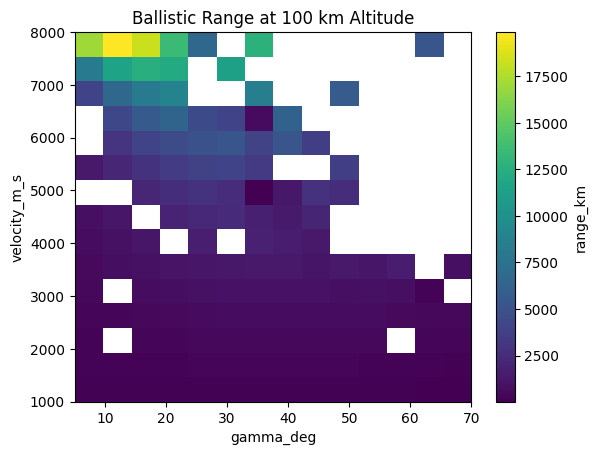

In [7]:
fig, ax = plt.subplots()
img = ax.imshow(df2.values, extent=(df2.columns.min(), df2.columns.max(), df2.index.min(), df2.index.max()), aspect="auto", origin="lower")
ax.set_xlabel("gamma_deg")
ax.set_ylabel("velocity_m_s")
cbar = fig.colorbar(img, ax=ax)
cbar.set_label("range_km")
ax.set_title(f"Ballistic Range at {selected_altitude} km Altitude")
plt.show()